In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor

# Preprocesamiento "rápido" para los baselines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Métricas y validación
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configuración 
from src.utils import DEV_SET_CLEAN_PATH, TARGET, COLS

# Configuración de plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Modelos base _sin_ preprocesamiento
Hacemos un preprocesamiento _muy_ básico para que los modelos puedan funcionar

In [2]:
df = pd.read_csv("../" + DEV_SET_CLEAN_PATH)

COLS_TO_DROP = [
    "id_grid",         
    "mes_listing",     
    "year",             
    "ITE_ADD_CITY_NAME", 
    "ITE_ADD_NEIGHBORHOOD_NAME", 
]

X = df.drop(columns=[TARGET] + COLS_TO_DROP)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

In [3]:
def print_model_metrics(y_true, y_pred, model_name):
    """Imprime métricas de un modelo"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"=== Modelo: {model_name} ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    print("-" * 50)

### 1.1 Dummy Regressor
Predice siempre la media

In [4]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print_model_metrics(y_test, y_pred_dummy, "Dummy Regressor")

=== Modelo: Dummy Regressor ===
RMSE: 681152.9130
MAE: 125955.5544
R2: -0.0000
--------------------------------------------------


### 1.2. Lasso Regression
Requiere un pipeline básico para que pueda funcionar

In [5]:
# Numéricas: Imputar mediana + Escalar 
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categóricas: Imputar moda + OneHot
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocesador
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Modelo completo
lasso_model = Pipeline([
    ('preprocessor', preprocessor_lasso),
    ('regressor', Lasso(alpha=1.0, random_state=42)) # Alpha controla la regularización
])

lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print_model_metrics(y_test, y_pred_lasso, "Lasso")

=== Modelo: Lasso ===
RMSE: 678821.4618
MAE: 120461.2442
R2: 0.0068
--------------------------------------------------


### 1.3. Decision Tree

=== Modelo: Decision Tree ===
RMSE: 666754.0966
MAE: 117732.5931
R2: 0.0418
--------------------------------------------------


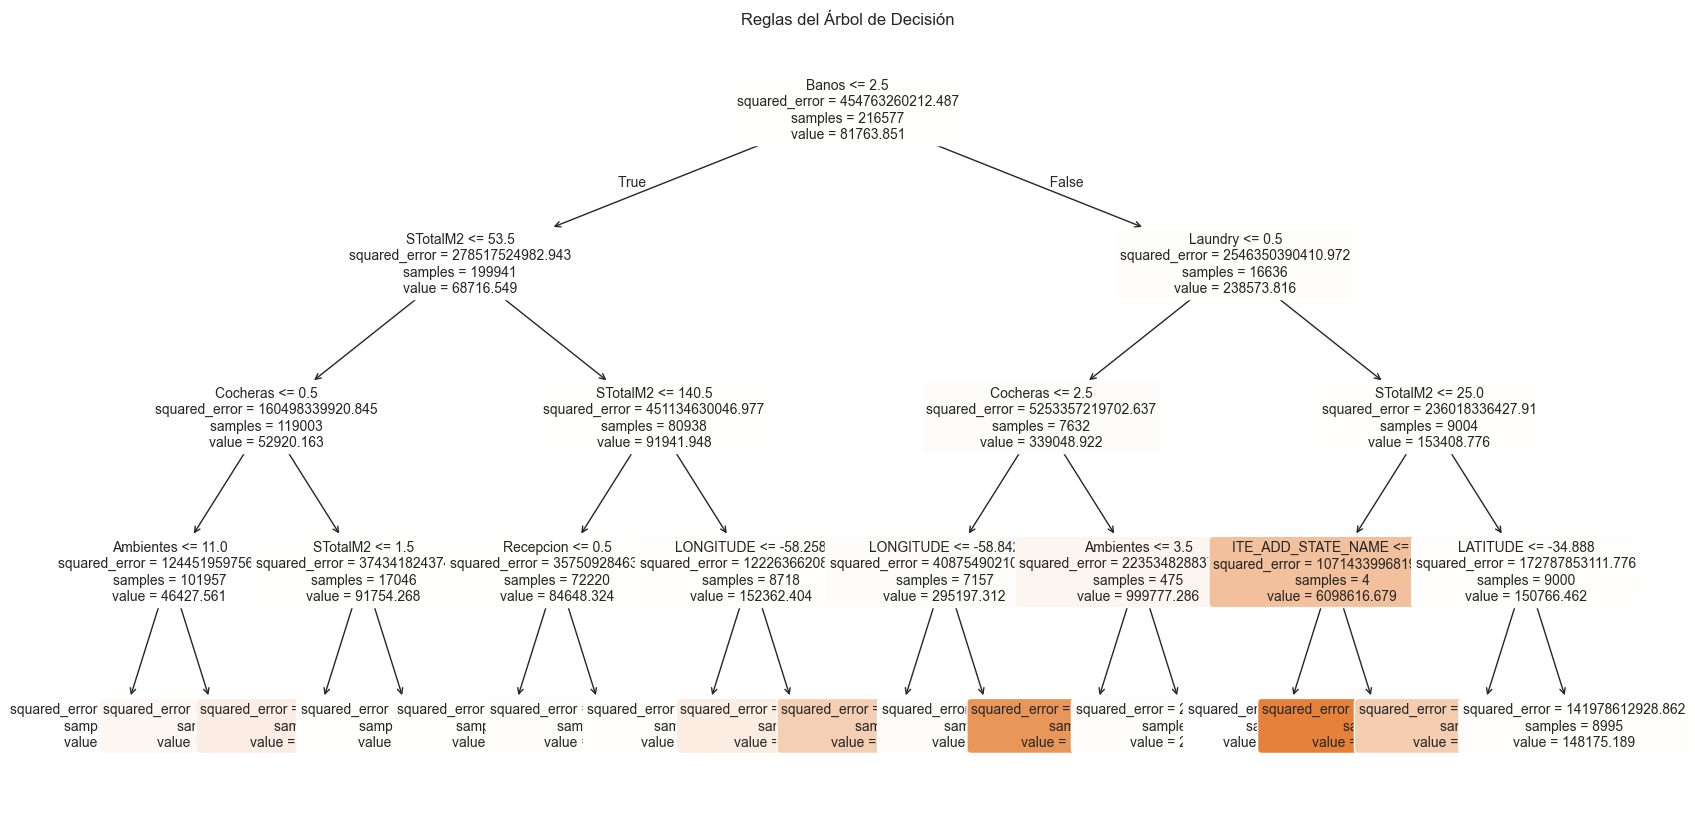

In [6]:
# Categóricas: imputar por la moda y Ordinal Encoder
categorical_transformer_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_cols), # XGB no necesita escalar
        ('cat', categorical_transformer_xgb, categorical_cols)
    ])

# Decision Tree
tree_model = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('regressor', DecisionTreeRegressor(max_depth=4, random_state=42)) 
    # Limitamos max_depth=4 para que sea interpretable y no un monstruo
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print_model_metrics(y_test, y_pred_tree, "Decision Tree")

# --- Visualización del Árbol ---
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model.named_steps['regressor'],
    feature_names=numeric_cols + categorical_cols, # Ojo: esto es aproximado con OrdinalEncoder
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Reglas del Árbol de Decisión")
plt.show()

### 1.4. XGBoost

In [7]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('regressor', XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1))
])

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print_model_metrics(y_test, y_pred_xgb, "XGBoost")

=== Modelo: XGBoost ===
RMSE: 465382.7416
MAE: 76602.0198
R2: 0.5332
--------------------------------------------------


/var/folders/6m/0x8b1d414hzb0yzldr8nbj5r0000gn/T/ipykernel_4566/2820727782.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='viridis')


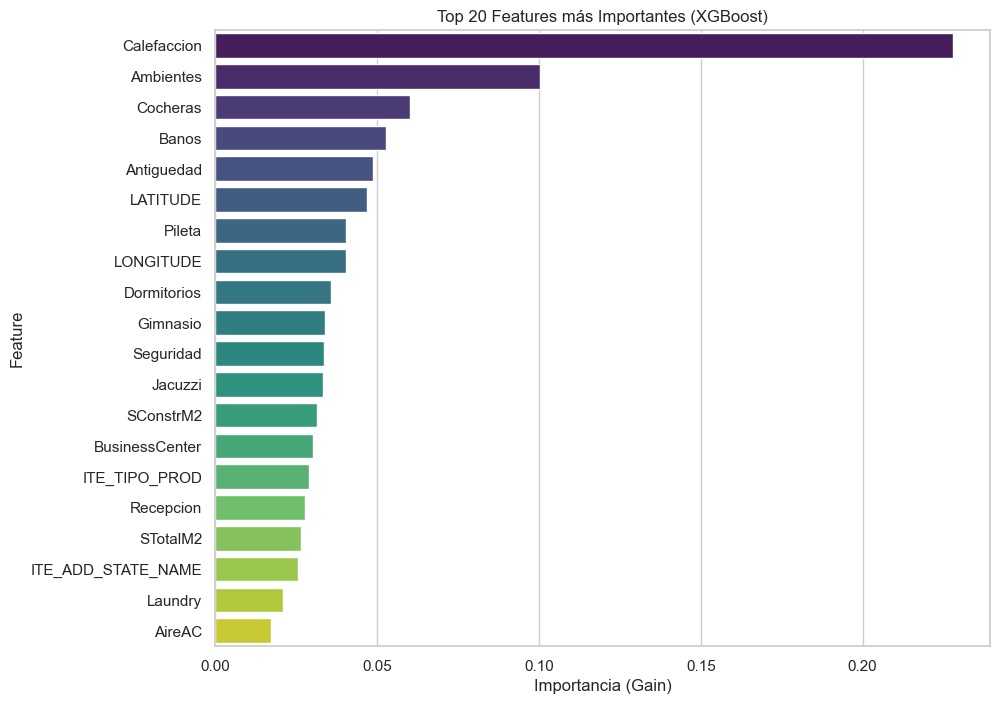

In [8]:
# Plotear importancia de features
xgb_regressor = xgb_model.named_steps['regressor']

importances = xgb_regressor.feature_importances_

feature_names = numeric_cols + categorical_cols

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("Top 20 Features más Importantes (XGBoost)")
plt.xlabel("Importancia (Gain)")
plt.show()

/var/folders/6m/0x8b1d414hzb0yzldr8nbj5r0000gn/T/ipykernel_4566/139142725.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Model', y='RMSE', palette='viridis')


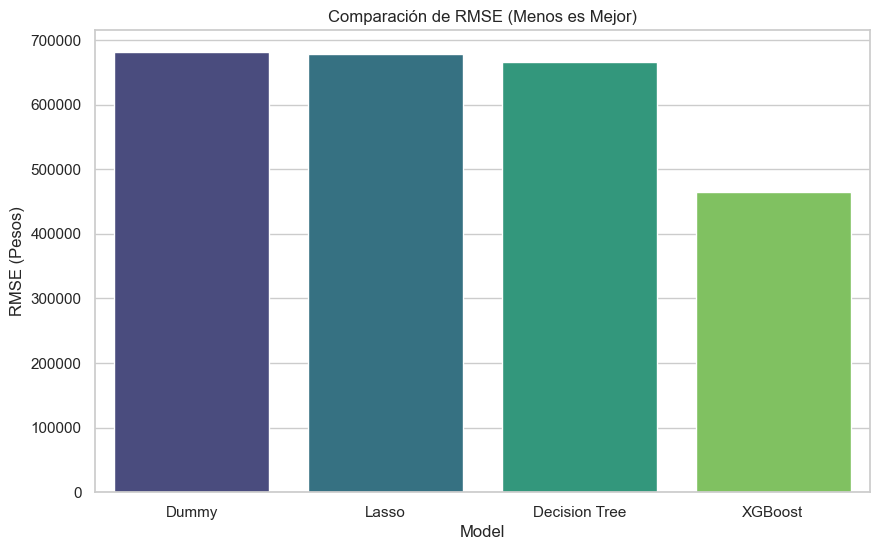

/var/folders/6m/0x8b1d414hzb0yzldr8nbj5r0000gn/T/ipykernel_4566/139142725.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Model', y='R2', palette='magma')


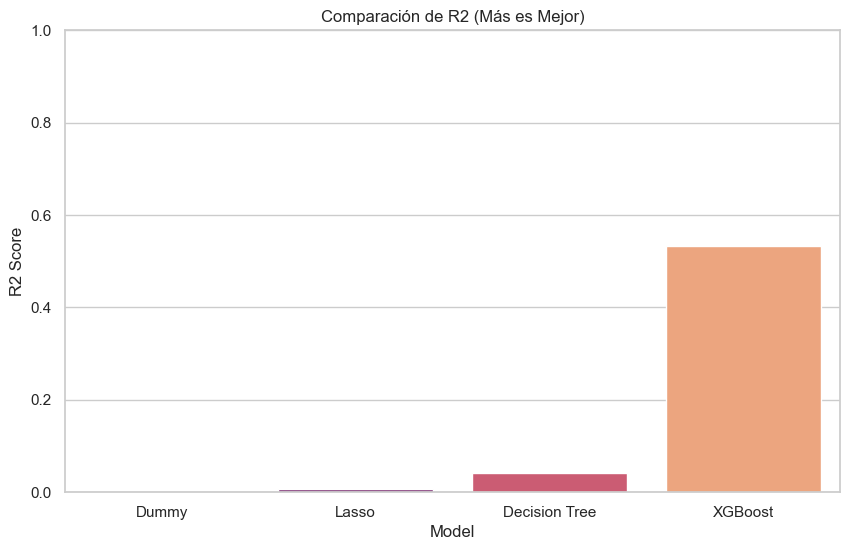


--- Tabla de Resultados ---


,Model,RMSE,R2
0,Dummy,681152.912984,-0.000008
1,Lasso,678821.461806,0.006826
2,Decision Tree,666754.096623,0.041823
3,XGBoost,465382.741553,0.533196


In [9]:
models_data = {
    'Model': ['Dummy', 'Lasso', 'Decision Tree', 'XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_dummy)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_tree)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    'R2': [
        r2_score(y_test, y_pred_dummy),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_xgb)
    ]
}

df_results = pd.DataFrame(models_data)

# Plot RMSE
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Model', y='RMSE', palette='viridis')
plt.title('Comparación de RMSE (Menos es Mejor)')
plt.ylabel('RMSE (Pesos)')
plt.show()

# Plot R2
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Model', y='R2', palette='magma')
plt.title('Comparación de R2 (Más es Mejor)')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # R2 teórico máximo es 1
plt.show()

print("\n--- Tabla de Resultados ---")
display(df_results)

# 2. Modelos base _con_ pipeline de preprocesamiento

Preparamos los pipelines

In [10]:
from src.config import pipeline_config
from src.pipeline import build_feature_pipeline, build_target_pipeline
from sklearn.compose import TransformedTargetRegressor

In [11]:
feature_pipeline = build_feature_pipeline(pipeline_config)
target_pipeline = build_target_pipeline(pipeline_config)

df_clean = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X_pipe = df_clean.drop(columns=[COLS.TARGET, COLS.BARRIO, COLS.CIUDAD]) # excluimos estas columnas porque todavía no están preprocesadas!!!
y_pipe = df_clean[[COLS.TARGET]]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pipe, y_pipe, test_size=0.2, random_state=42)


### 2.1 Lasso Regression

In [13]:
lasso_pipe_model = TransformedTargetRegressor(
    regressor=Lasso(alpha=0.001, random_state=42),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False
)

full_lasso = Pipeline([
    ('preprocessor', feature_pipeline),
    ('model', lasso_pipe_model)
])

# Nota: Al usar func/inverse, no clipeamos el target automáticamente.
# Si los outliers son muy graves, el log igual ayuda mucho.
full_lasso.fit(X_train_p, y_train_p)
y_pred_lasso_p = full_lasso.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_lasso_p, "Lasso (Preprocesado)")


=== Modelo: Lasso (Preprocesado) ===
RMSE: 682685.4856
MAE: 68185.8317
R2: -0.0045
--------------------------------------------------


In [17]:
tree_pipe_model = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(max_depth=4, random_state=42),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False
)

full_tree = Pipeline([
    ('preprocessor', feature_pipeline),
    ('model', tree_pipe_model)
])

full_tree.fit(X_train_p, y_train_p)
y_pred_tree_p = full_tree.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_tree_p, "Decision Tree (Preprocesado)")

=== Modelo: Decision Tree (Preprocesado) ===
RMSE: 682786.0335
MAE: 69485.3957
R2: -0.0048
--------------------------------------------------


In [18]:
xgb_pipe_model = TransformedTargetRegressor(
    regressor=XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=10, random_state=42, n_jobs=-1),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False
)

full_xgb = Pipeline([
    ('preprocessor', feature_pipeline),
    ('model', xgb_pipe_model)
])

full_xgb.fit(X_train_p, y_train_p)
y_pred_xgb_p = full_xgb.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_xgb_p, "XGBoost (Preprocesado)")

=== Modelo: XGBoost (Preprocesado) ===
RMSE: 539377.2376
MAE: 48583.9570
R2: 0.3730
--------------------------------------------------


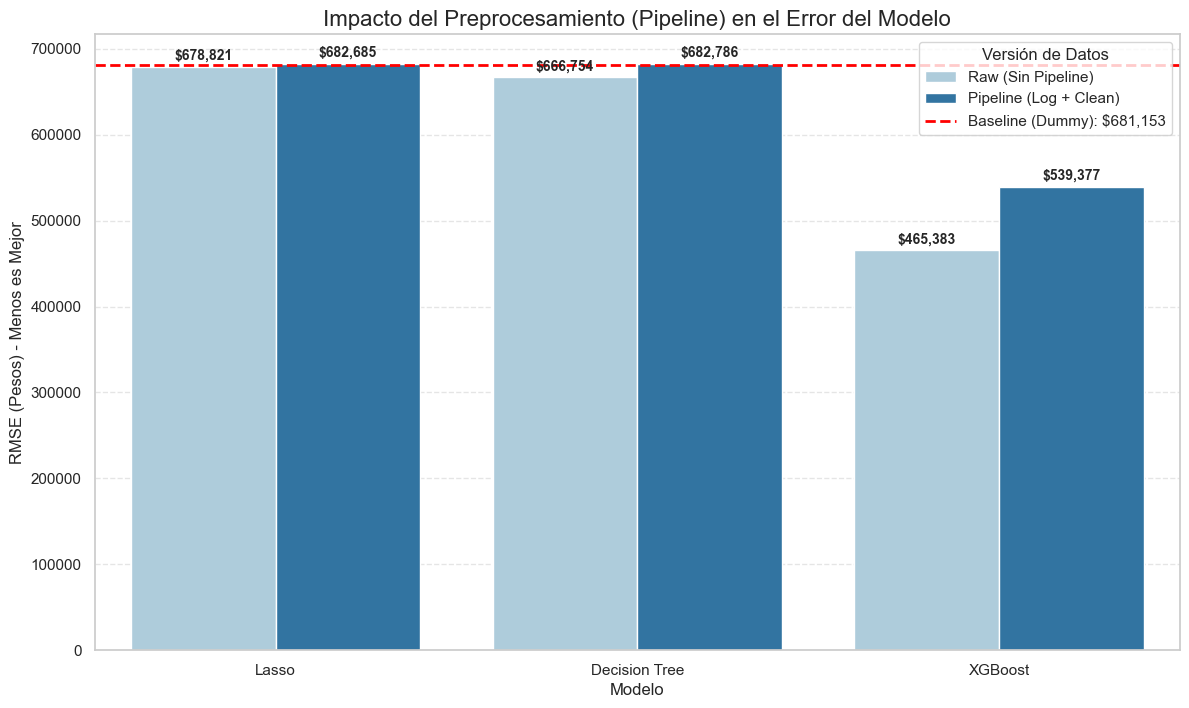


--- Mejora Porcentual del Pipeline vs Raw ---
Lasso: El error bajó de $678,821 a $682,685 (Mejora del -0.6%)
Decision Tree: El error bajó de $666,754 a $682,786 (Mejora del -2.4%)
XGBoost: El error bajó de $465,383 a $539,377 (Mejora del -15.9%)


In [19]:
# --- 6. Comparación Final: Raw vs Pipeline ---

# 1. Recopilar métricas
comparison_data = []

# Modelos Raw (usamos y_test original)
comparison_data.append({'Model': 'Lasso', 'Type': 'Raw (Sin Pipeline)', 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso))})
comparison_data.append({'Model': 'Decision Tree', 'Type': 'Raw (Sin Pipeline)', 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_tree))})
comparison_data.append({'Model': 'XGBoost', 'Type': 'Raw (Sin Pipeline)', 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb))})

# Modelos Pipeline (usamos y_test_p)
comparison_data.append({'Model': 'Lasso', 'Type': 'Pipeline (Log + Clean)', 'RMSE': np.sqrt(mean_squared_error(y_test_p, y_pred_lasso_p))})
comparison_data.append({'Model': 'Decision Tree', 'Type': 'Pipeline (Log + Clean)', 'RMSE': np.sqrt(mean_squared_error(y_test_p, y_pred_tree_p))})
comparison_data.append({'Model': 'XGBoost', 'Type': 'Pipeline (Log + Clean)', 'RMSE': np.sqrt(mean_squared_error(y_test_p, y_pred_xgb_p))})

df_compare = pd.DataFrame(comparison_data)

# 2. Graficar
plt.figure(figsize=(14, 8))

# Barplot agrupado
ax = sns.barplot(data=df_compare, x='Model', y='RMSE', hue='Type', palette='Paired')

# Línea de Baseline (Dummy)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
plt.axhline(y=dummy_rmse, color='red', linestyle='--', linewidth=2, label=f'Baseline (Dummy): ${dummy_rmse:,.0f}')

# Etiquetas de valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', padding=3, fontsize=10, fontweight='bold')

plt.title('Impacto del Preprocesamiento (Pipeline) en el Error del Modelo', fontsize=16)
plt.ylabel('RMSE (Pesos) - Menos es Mejor', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.legend(title='Versión de Datos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 3. Tabla de Mejoras
print("\n--- Mejora Porcentual del Pipeline vs Raw ---")
models = ['Lasso', 'Decision Tree', 'XGBoost']
for model in models:
    raw = df_compare[(df_compare['Model'] == model) & (df_compare['Type'] == 'Raw (Sin Pipeline)')]['RMSE'].values[0]
    pipe = df_compare[(df_compare['Model'] == model) & (df_compare['Type'] == 'Pipeline (Log + Clean)')]['RMSE'].values[0]
    improvement = (raw - pipe) / raw * 100
    print(f"{model}: El error bajó de ${raw:,.0f} a ${pipe:,.0f} (Mejora del {improvement:.1f}%)")